
# Transfer Learning


In [29]:
import torch
import torchvision
from torchvision.transforms import v2

import torchinfo

import matplotlib.pyplot as plt
import numpy as np
import time

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, './util')
import vcpi_util


from tqdm import tqdm

In [66]:
def train(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix = 'model'):

    history = {}
    history['accuracy'] = []
    history['val_acc'] = []
    history['val_loss'] = []
    history['loss'] = []
    best_val_loss = np.inf

    for epoch in range(epochs):  # loop over the dataset multiple times

        model.train()
        start_time = time.time() 
        correct = 0
        running_loss = 0.0
        for i, (inputs, targets) in tqdm(enumerate(train_loader, 0)):
            
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            loss = loss_fn(outputs, targets)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.cpu().detach().numpy()
            correct += (predicted == targets).sum().cpu().detach().numpy()

        model.eval()
        v_correct = 0
        val_loss = 0.0
        with torch.no_grad():
            for i,t in val_loader:
                i = i.to(device)
                t = t.to(device)
                o = model(i)
                _,p = torch.max(o,1)
                
                #with torch.no_grad():
                val_loss += loss_fn(o, t).cpu().detach().numpy()

                v_correct += (p == t).sum().cpu().detach().numpy()

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        
        if old_lr != new_lr:
            print('==> Learning rate updated: ', old_lr, ' -> ', new_lr)

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = 100 * correct / len(train_loader.dataset)
        v_accuracy = 100 * v_correct / len(val_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)
        stop_time = time.time()
        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.6f}; Accuracy: {accuracy:0.4f}; Val Loss: {val_loss:0.6f}; Val Acc: {v_accuracy:0.4f}; Elapsed time: {(stop_time - start_time):0.4f}')
        history['accuracy'].append(accuracy)
        history['val_acc'].append(v_accuracy)
        history['val_loss'].append(val_loss)
        history['loss'].append(epoch_loss)
 
        ###### Saving ######
        if val_loss < best_val_loss:
           
            torch.save({
                'epoch': epoch,
                'model':model.state_dict(),
                'history': history,
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
                },
                f'{save_prefix}_best.pt')

        if early_stopper(val_loss):
            print('Early stopping!')
            break
        
    print('Finished Training')

    return(history)


def evaluate(model, data_loader):

    # sets the model in evaluation mode.
    # although our model does not have layers which behave differently during training and evaluation
    # this is a good practice as the models architecture may change in the future
    model.eval()

    correct = 0
    
    for i, (images, targets) in enumerate(data_loader):
         
        # forward pass, compute the output of the model for the current batch
        outputs = model(images.to(device))

        # "max" returns a namedtuple (values, indices) where values is the maximum 
        # value of each row of the input tensor in the given dimension dim; 
        # indices is the index location of each maximum value found (argmax).
        # the argmax effectively provides the predicted class number        
        _, preds = torch.max(outputs, dim=1)

        correct += (preds.cpu() == targets).sum()

    return (correct / len(data_loader.dataset)).item()


class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta

        self.min_delta
        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False
    


def build_confusion_matrix(model, dataset):

    preds = []
    ground_truth = []

    for images, targets in dataset:

        predictions = model(images.to(device))
        preds_sparse = [np.argmax(x) for x in predictions.cpu().detach().numpy()]
        preds.extend(preds_sparse)
        ground_truth.extend(targets.numpy())

    vcpi_util.show_confusion_matrix(ground_truth, preds, len(test_set.classes))  


def inverse_normalize(tensor, mean, std):
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return tensor

def show_bad_preds(model, dataset, classes):
    k = 0
    iters = 0

    preds = []
    ground_truth = []
    imgs = torch.Tensor(52, 3, 128,128)

    iterator = iter(dataset)

    max_iters = test_set.__len__() / BATCH_SIZE
    while k < 52 and iters < max_iters:

        images, targets = next(iterator)
        #print(images[0].shape)
        logits = model(images.to(device))
        
        #print(predictions[0])
        predictions = torch.nn.functional.softmax(logits, dim=1).cpu().detach().numpy()
        for i in range(len(predictions)):

            if np.argmax(predictions[i]) != targets[i] and k < 52:

                preds.append(predictions[i])
                ground_truth.append(targets[i])
                imgs[k, :, :, :] = inverse_normalize(images[i],[0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
                k += 1

        iters += 1

    vcpi_util.plot_predictions(imgs, preds, ground_truth, classes, 13, 4)        


## Settings

In [31]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

BATCH_SIZE = 32

IMG_SIZE = 128

EPOCHS = 30

SAMPLES = 23000

prefix = 'd:/vcpi/dogsVScats'

PATH_TEST_SET = f'{prefix}/test'
PATH_VAL_SET =f'{prefix}/val{SAMPLES}'

PATH_TRAINING_SET = f'{prefix}/train{SAMPLES}'

TRAIN = True

cuda:0


## The dataset: Dogs Vs Cats

Original data set can be found in: https://www.kaggle.com/c/dogs-vs-cats/data

![image](notebook_images/dogs_vs_cats.png)

The dataset consists of 25000 thousand images from cats and dogs. 2000 images were randomly collected for the test set. From the remaining 23000 images, 20% were used for the validation set.



In [53]:
from torchvision.transforms import v2

train_transform = v2.Compose([
        v2.Resize((IMG_SIZE,IMG_SIZE)),
        v2.RandomHorizontalFlip(),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

test_transform = v2.Compose([
        v2.Resize((IMG_SIZE,IMG_SIZE)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

train_set = torchvision.datasets.ImageFolder(root=PATH_TRAINING_SET, transform = train_transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size = BATCH_SIZE, shuffle=True)

# No shuffle is required for the test set, also the batch size can be completely different
test_set = torchvision.datasets.ImageFolder(root=PATH_TEST_SET, transform = train_transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = BATCH_SIZE, shuffle=True)

val_set = torchvision.datasets.ImageFolder(root=PATH_VAL_SET, transform = test_transform)
val_loader = torch.utils.data.DataLoader(val_set, batch_size = BATCH_SIZE)


In [33]:
images, targets = next(iter(train_loader))
print("Batch shape: ", images.shape)


Batch shape:  torch.Size([32, 3, 128, 128])


Displaying some images after the transform has been applied.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

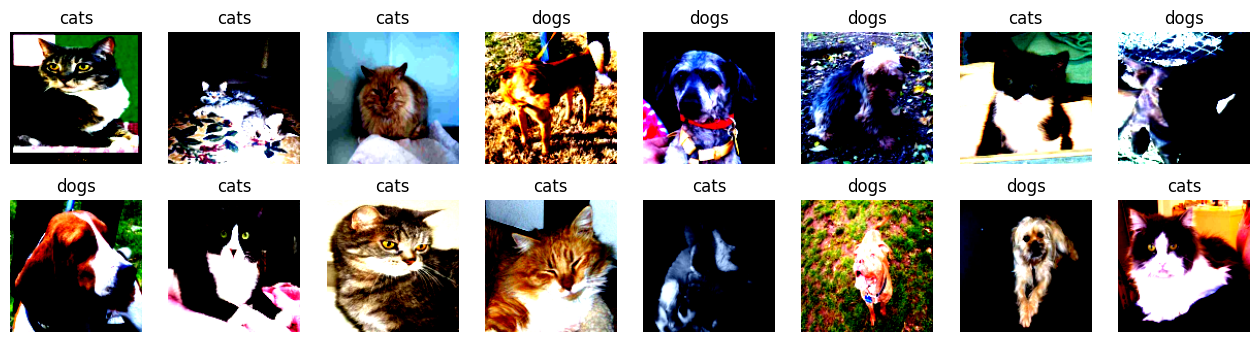

<Figure size 640x480 with 0 Axes>

In [34]:
vcpi_util.show_images(2,8, images, targets, train_set.classes) 

## Explore torchvision models

Pytorch info on models and pretrained weights: https://pytorch.org/vision/stable/models.html

### Listing all models available in torchvision

In [35]:
model_names = torchvision.models.list_models(module=torchvision.models)
print(model_names)

['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'densenet121', 'densenet161', 'densenet169', 'densenet201', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_v2_l', 'efficientnet_v2_m', 'efficientnet_v2_s', 'googlenet', 'inception_v3', 'maxvit_t', 'mnasnet0_5', 'mnasnet0_75', 'mnasnet1_0', 'mnasnet1_3', 'mobilenet_v2', 'mobilenet_v3_large', 'mobilenet_v3_small', 'regnet_x_16gf', 'regnet_x_1_6gf', 'regnet_x_32gf', 'regnet_x_3_2gf', 'regnet_x_400mf', 'regnet_x_800mf', 'regnet_x_8gf', 'regnet_y_128gf', 'regnet_y_16gf', 'regnet_y_1_6gf', 'regnet_y_32gf', 'regnet_y_3_2gf', 'regnet_y_400mf', 'regnet_y_800mf', 'regnet_y_8gf', 'resnet101', 'resnet152', 'resnet18', 'resnet34', 'resnet50', 'resnext101_32x8d', 'resnext101_64x4d', 'resnext50_32x4d', 'shufflenet_v2_x0_5', 'shufflenet_v2_x1_0', 'shufflenet_v2_x1_5', 'shufflenet_v2_x2_0', 'squeezenet1_0

## VGG 16

VGG16 was proposed in [“Very Deep Convolutional Networks For Large-Scale Image Recognition”](https://arxiv.org/pdf/1409.1556.pdf)

Most models are composed by blocks. From a very high level point of view (and somewhat simplified view) one can see the initial blocks as feature extractors, they gather information about the input image. This information is passed from layer to layer until it reaches the last block. This last block is then responsible for the classification.

VGG16 was originally built for ImageNet, a 1000 class problem. Our dataset has only two classes: cats and dogs. To reuse such a model we keep the feature extraction blocks and replace the last block, or head, of the model.

In [36]:
# Example: loading a model with pre-trained weights
model = torchvision.models.vgg16()
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Probing some information

In [37]:
print(model.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)


In [38]:
print(model.classifier[0])

Linear(in_features=25088, out_features=4096, bias=True)


In [39]:
print(model.classifier[0].in_features)

25088


### Adapting VGG16 for a two class problem

Now, we are creating a version of the VGG16 for our particular problem. 

To achieve this we replace the classifier block, with a block suitable for classification in a 2 class problem

First create the model

In [40]:
model = torchvision.models.vgg16()
model.to(device)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

Now, replace the classifier block with our own. As we are dealing with only 2 classes, our classifier will be lighter than the original.

In [41]:
# get the number of inputs of the classification block
n_inputs = model.classifier[0].in_features

# replace the classifier block with a block consisting of two dense layers.
model.classifier = torch.nn.Sequential(
    torch.nn.Linear(n_inputs, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 2)
)
model.to(device)
print(model)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [42]:
torchinfo.summary(model, input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE))

Layer (type:depth-idx)                   Output Shape              Param #
VGG                                      [32, 2]                   --
├─Sequential: 1-1                        [32, 512, 4, 4]           --
│    └─Conv2d: 2-1                       [32, 64, 128, 128]        1,792
│    └─ReLU: 2-2                         [32, 64, 128, 128]        --
│    └─Conv2d: 2-3                       [32, 64, 128, 128]        36,928
│    └─ReLU: 2-4                         [32, 64, 128, 128]        --
│    └─MaxPool2d: 2-5                    [32, 64, 64, 64]          --
│    └─Conv2d: 2-6                       [32, 128, 64, 64]         73,856
│    └─ReLU: 2-7                         [32, 128, 64, 64]         --
│    └─Conv2d: 2-8                       [32, 128, 64, 64]         147,584
│    └─ReLU: 2-9                         [32, 128, 64, 64]         --
│    └─MaxPool2d: 2-10                   [32, 128, 32, 32]         --
│    └─Conv2d: 2-11                      [32, 256, 32, 32]         29

### Training from scratch

In [45]:
loss_fn = torch.nn.CrossEntropyLoss()

early_stop = Early_Stopping(9, min_delta = 0.000001)
optimizer = torch.optim.Adam(model.parameters())
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor = 0.1, patience=3) 

if TRAIN:
    history = train(model, train_loader, val_loader, EPOCHS, loss_fn, optimizer, scheduler, early_stop, f'vgg16')

reload = torch.load(f'vgg16_best.pt')
print(reload['epoch'])
model.load_state_dict(reload['model'])


10


<All keys matched successfully>

### Evaluate the model

In [56]:
evaluate(model, test_loader)

0.5

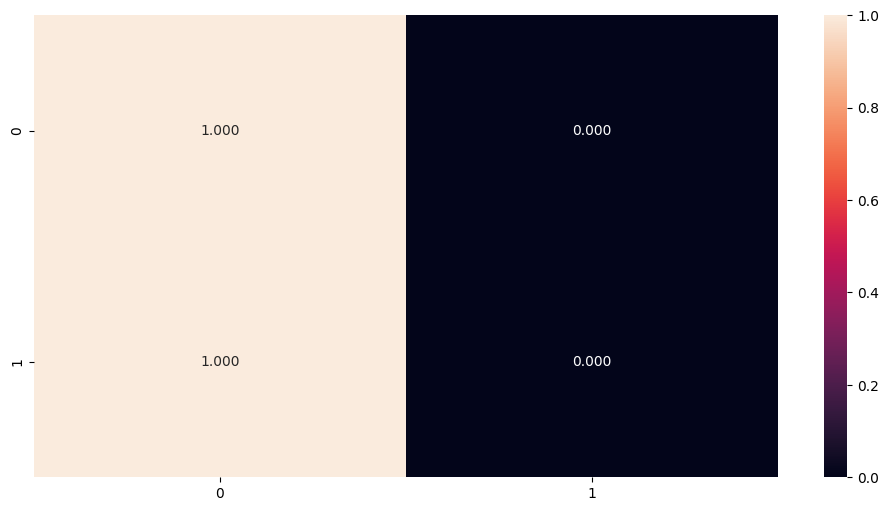

In [57]:
build_confusion_matrix(model, test_loader)

Checking the actual predictions

In [58]:
iterator = iter(test_loader)
images, targets = next(iterator)
logits = model(images.to(device))
print(logits)


tensor([[0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439],
        [0.0443, 0.0439]], device='cuda:0', grad_fn=<AddmmBackward0>)


The model fails to learn effectively, consistently reporting an accuracy of around 50%. It predicts the same class—"cat"—for every input, indicating that it is not capturing any meaningful patterns from the data.

While this is a simple experiment, it clearly highlights that the task is significantly more challenging than the datasets used in previous notebooks.

## Transfer Learning

The goal of transfer learning is to leverage knowledge from a model pre-trained on a large dataset and apply it to a new, often smaller, dataset.

This approach benefits from the fact that the feature extraction layers have already learned useful representations. As a result, training is typically faster and the resulting model often performs better, even with limited data.

Most pre-trained models are structured in blocks. At a high level (and in simplified terms), the early blocks act as feature extractors, capturing patterns such as edges, textures, and shapes. These features are passed through successive layers until they reach the final block, which performs the classification.

Many of these models have been trained on the ImageNet-1K dataset, and their pre-trained weights are readily available in torchvision. For a complete list, refer to the PyTorch [documentation](https://pytorch.org/vision/stable/models).

Transfer learning typically involves two phases:

- Phase 1: Freeze all blocks except the classifier. Only the classifier’s weights are updated during training.

- Phase 2: Gradually unfreeze some or all of the feature extraction blocks and fine-tune the model further.

### Creating the model



VGG16 was originally built for ImageNet, a 1000 class problem. Our dataset has only two classes: cats and dogs. To adapt the model to this dataset we are performing
Performing the following steps on VGG-16:

- load the original VGG16 with pretrained weights for the ImageNet dataset
- freeze all the weights
- replace the original classifier 

In [59]:
# load model from torchs repo, with pretrained weights from ImageNet
model = torchvision.models.vgg16(weights = torchvision.models.VGG16_Weights.IMAGENET1K_V1)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

n_inputs = model.classifier[0].in_features

model.classifier = torch.nn.Sequential(
    torch.nn.Linear(n_inputs, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 2)
)
model.to(device)
print(model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### Training and Evaluating

In [61]:
loss_fn = torch.nn.CrossEntropyLoss()

early_stop = Early_Stopping(9, min_delta = 0.000001)
optimizer = torch.optim.Adam(model.parameters())
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor = 0.1, patience=3)    

if TRAIN:
    history = train(model, train_loader, val_loader, EPOCHS, loss_fn, optimizer, scheduler, early_stop, f'vgg16_tl_{SAMPLES}')

reload = torch.load(f'vgg16_tl_{SAMPLES}_best.pt')
print(reload['epoch'])
model.load_state_dict(reload['model'])
evaluate(model, test_loader)

13


0.9745000004768372

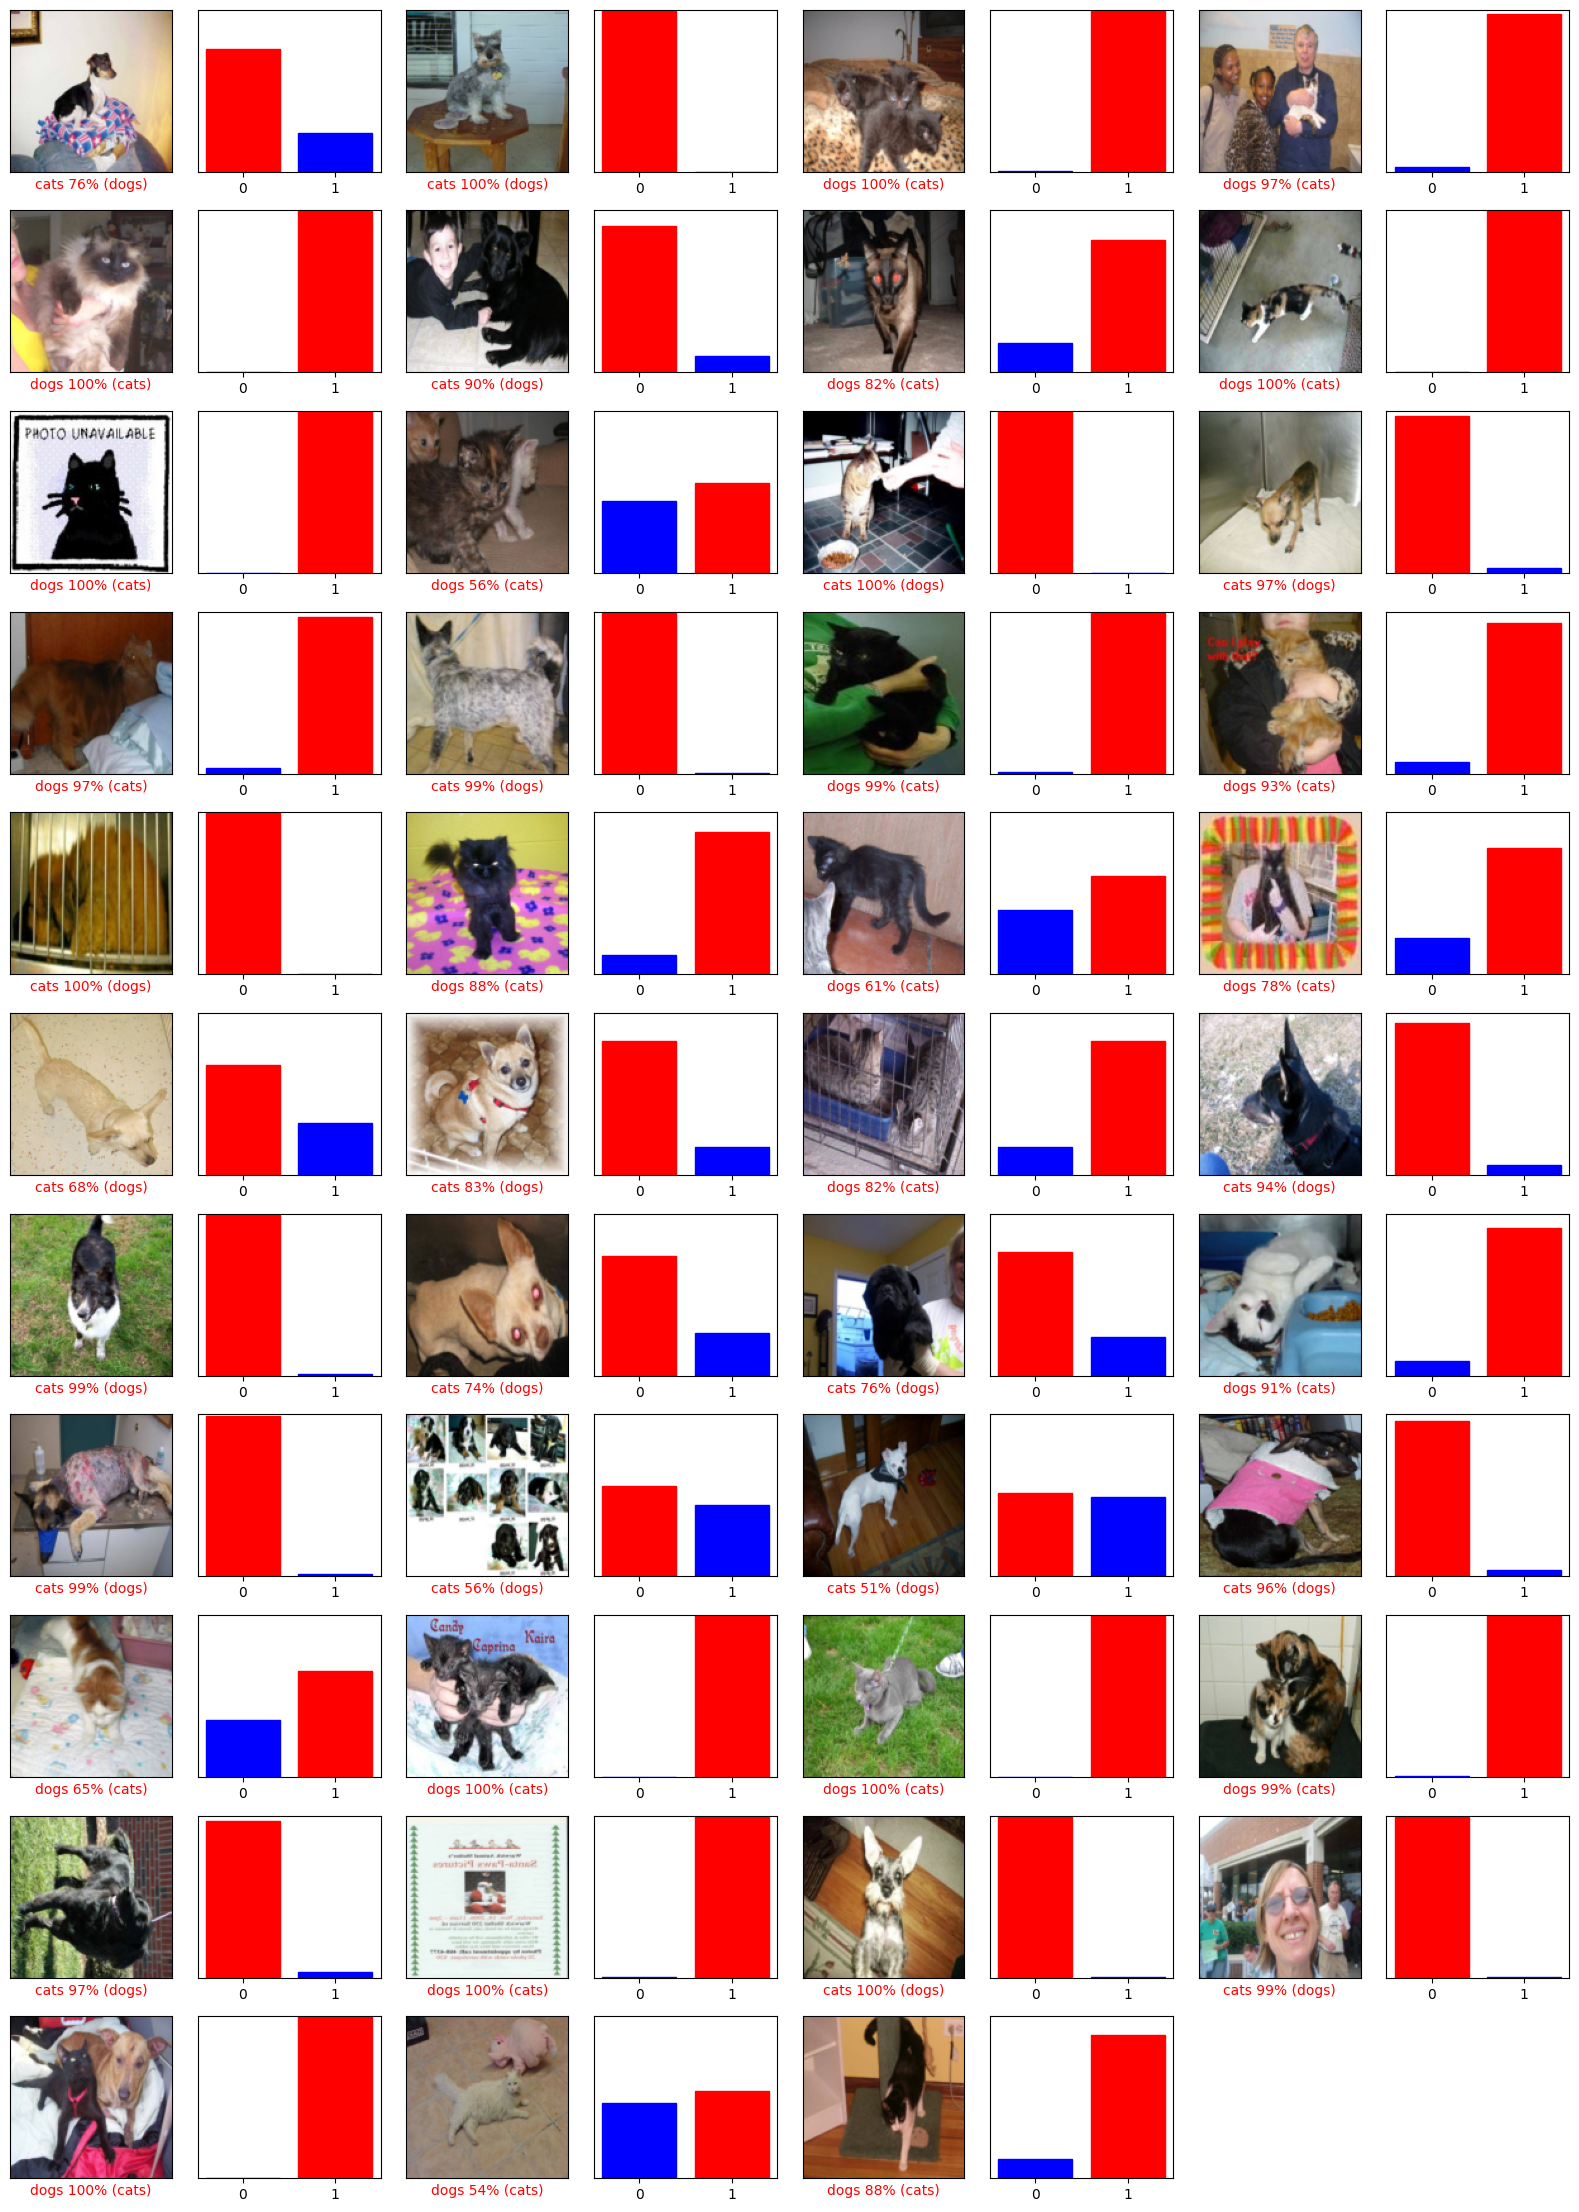

In [67]:
show_bad_preds(model, test_loader, test_loader.dataset.classes)

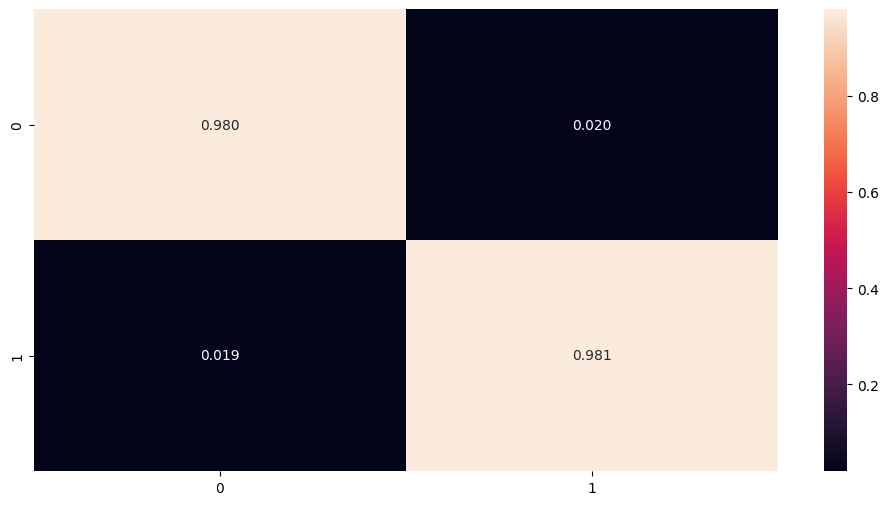

In [65]:
build_confusion_matrix(model, test_loader)